In [15]:
import sys
import os
sys.path.append(os.path.abspath("../clean_code/"))

In [48]:
from Visualization import generalVisualization
from Visualization import scatter_visualization
from Visualization import visualHelpers
from Utilities import shuffle
from Utilities import config
from Utilities import reader
import pickle
import select_landmarks_MI
import importlib
import voltagemap
import main
import kmeans
import matplotlib.pyplot as plt
import numpy as np

In [83]:
importlib.reload(generalVisualization)
importlib.reload(shuffle)
importlib.reload(scatter_visualization)
importlib.reload(visualHelpers)
importlib.reload(voltagemap)
importlib.reload(main)
importlib.reload(kmeans)

<module 'kmeans' from '/home/avighna/Documents/python/VoltageDimentionalReduction/clean_code/kmeans.py'>

In [21]:
config.params['file_path']= '../../Voltage_Data/mnist/mnist.csv'
config.params['split_char']= ','
config.params['normalize_vecs']= False

config.params['max_centroids']= 1000
config.params['init_size']= 10000
config.params['batch_size']= 10000
config.params['output']= '../../Voltage_Temp/Results/streaming_centroids.npy'
config.params['save_data'] = '../../Voltage_Temp/Results/saved_data.pkl'
config.params['k']=10
config.params['r']=1
config.params['alpha']=0.1
config.params['equalize_centroids']=True
config.params['NoOfLandmarks']=10
config.params['DepthOfLandmarkSearch']=100

In [43]:
data_to_save = main.main()

Read 10000 vectors
Estimated max pairwise distance squared, FAISS) = 16654926.0000
 Estimated minimum distance squared = 71864.0000
10 vectors in index after adding initial centroid
Read 20000 vectors
number of centroids: 1000, max_centroids: 1000
Reached maximum number of centroids: 1000
Read 30000 vectors
refining vectors
sorted_sizes=[94 81 63 63 57]
too_small=48, rms=55.16764352378823, finished=False

refining vectors
sorted_sizes=[91 81 60 58 53]
too_small=48, rms=52.584372015236774, finished=False

refining vectors
sorted_sizes=[89 80 58 54 52]
too_small=48, rms=50.43011124737247, finished=False

refining vectors
sorted_sizes=[87 78 57 50 49]
too_small=48, rms=48.61948131697308, finished=False

refining vectors
sorted_sizes=[88 78 56 50 48]
too_small=48, rms=47.08827703156349, finished=False

refining vectors
sorted_sizes=[86 73 54 52 48]
too_small=48, rms=45.820374690588125, finished=False

refining vectors
sorted_sizes=[86 71 53 51 49]
too_small=48, rms=44.73901252383278, finis

In [44]:
data_to_save['voltage_map'] = select_landmarks_MI.select_landmarks(data_to_save['all_voltages'])

Starting landmark selection based on mutual information took 0.00 seconds
calculated MI for each singleton took 78.16 seconds
Adding landmark index=0 lm_index=818 with MI=0.3892
Adding landmark index=1 lm_index=40 with MI=0.7848
Adding landmark index=5 lm_index=84 with MI=1.1130
Adding landmark index=3 lm_index=745 with MI=1.4693
Adding landmark index=6 lm_index=778 with MI=1.8154
Adding landmark index=11 lm_index=145 with MI=2.1417
Adding landmark index=6 lm_index=95 with MI=2.5101
Adding landmark index=27 lm_index=89 with MI=2.7376
Adding landmark index=29 lm_index=162 with MI=3.0799
Adding landmark index=14 lm_index=174 with MI=3.2433
Selected 10 landmarks based on mutual information took 92.01 seconds


In [23]:
with open(config.params['save_data'], 'wb') as f:
    pickle.dump(data_to_save, f)

In [69]:
with open(config.params['save_data'], 'rb') as f:
    data_to_save = pickle.load(f)

In [70]:
voltages = data_to_save['voltage_map']
centroids = data_to_save['centroids']
label_counts = data_to_save['label_counts']
points = voltages.voltage_array()
transformed_points = visualHelpers.transform(points, 'pca')

In [71]:
[landmark.index for landmark in voltages.get_all_landmarks()]

[174, 162, 89, 95, 145, 778, 745, 84, 40, 818]

In [72]:
print(type(points))
print(type(centroids))
print(type(label_counts))

<class 'numpy.ndarray'>
<class 'setofpoints.SetOfPoints'>
<class 'list'>


In [73]:
print(points.shape)
print(len(centroids))
print(len(label_counts))

(1000, 10)
1000
1000


Number of point_voltages with no label: 258
Plot saved to mnist_visualization.png


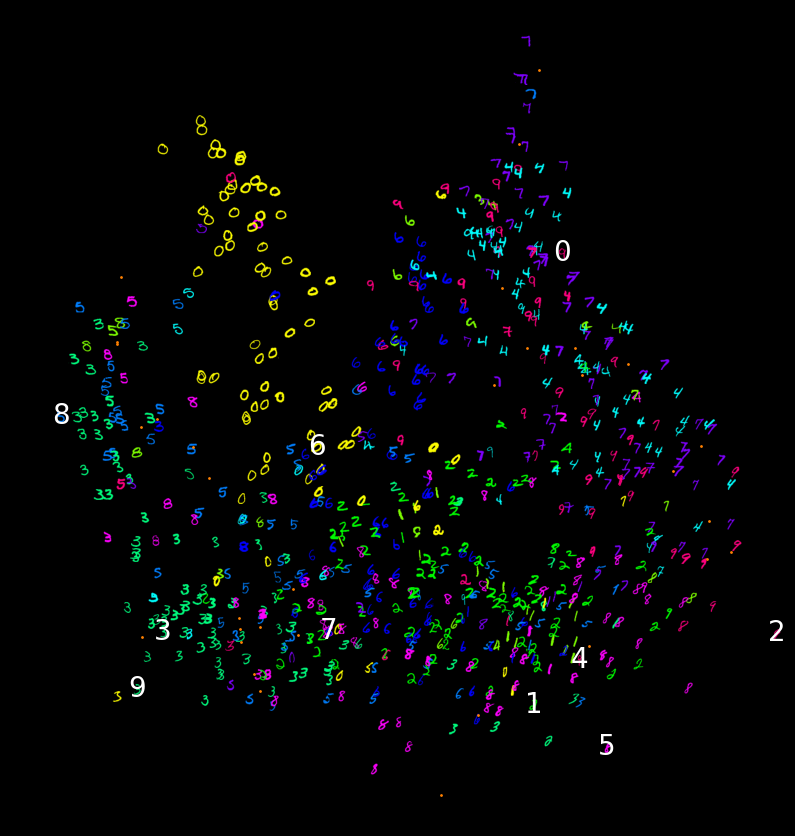

In [77]:
focus_on = np.array([0,1,2,3,4,5,6,7,8,9])
scatter_visualization.plot_landmark_subset(points, centroids, label_counts, focus_on, alpha_actual=1, element='digit')

Number of point_voltages with no label: 124
Plot saved to mnist_visualization.png


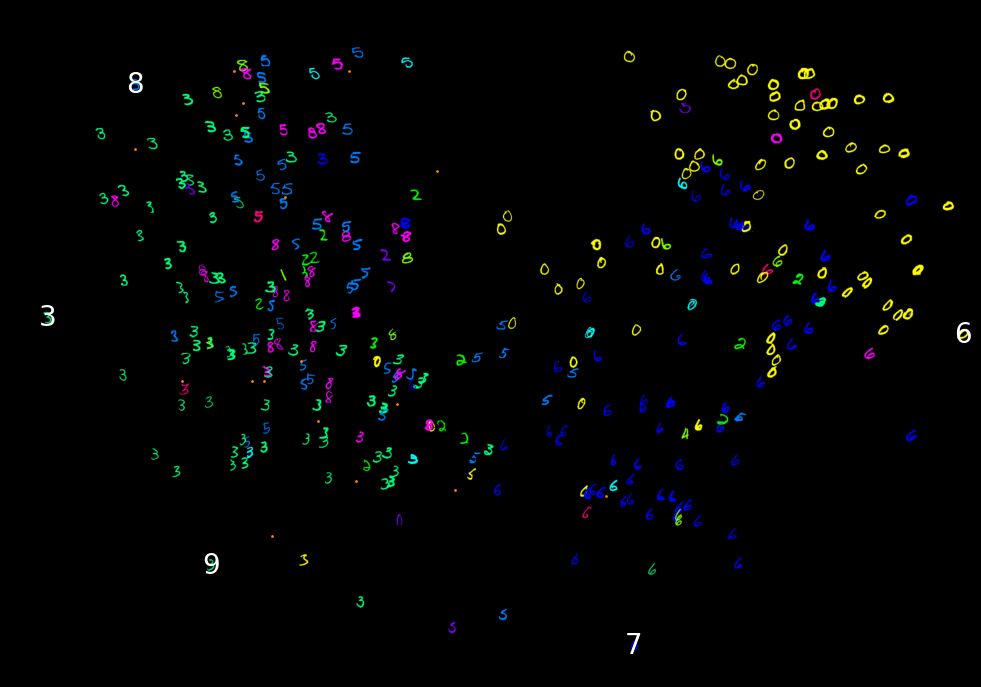

In [78]:
focus_on = np.array([3,6,7,8,9])
scatter_visualization.plot_landmark_subset(points, centroids, label_counts, focus_on, alpha_actual=1, element='digit')

<class 'voltagemap.VoltageMap'>
Number of landmarks: 10
Number of point_voltages with no label: 0
Plot saved to mnist_visualization.png


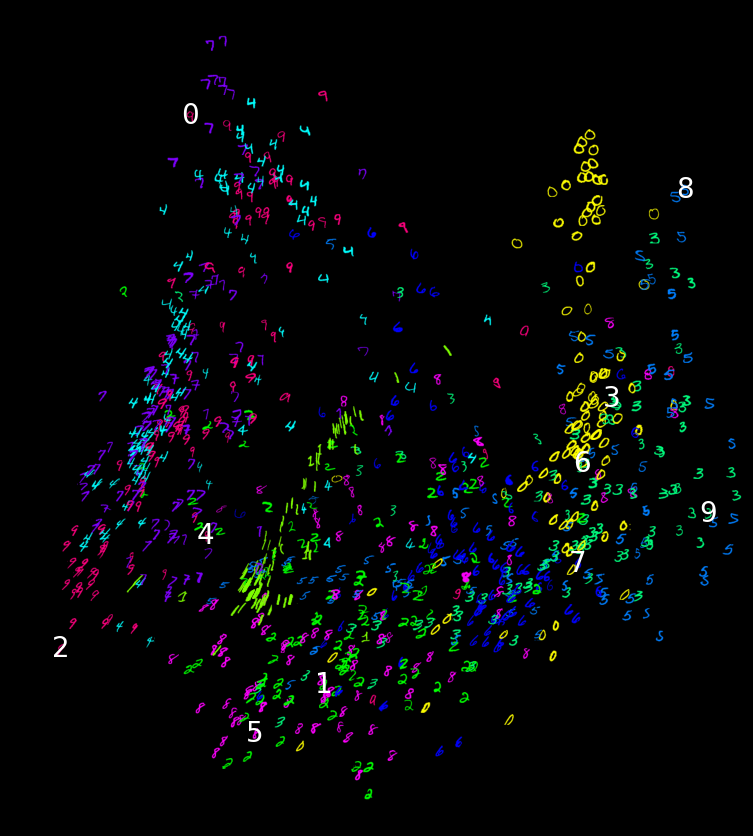

In [91]:
focus_on = np.array([0,1,2,3,4,5,6,7,8,9])
scatter_visualization.plot_points_from_file(config.params['file_path'], 1000, points, centroids, voltages, label_counts, 
                                            focus_on=focus_on, element='digit', size_threshold=0)

Read 10000 vectors<class 'voltagemap.VoltageMap'>
Number of landmarks: 10
Number of point_voltages with no label: 0
Plot saved to mnist_visualization.png


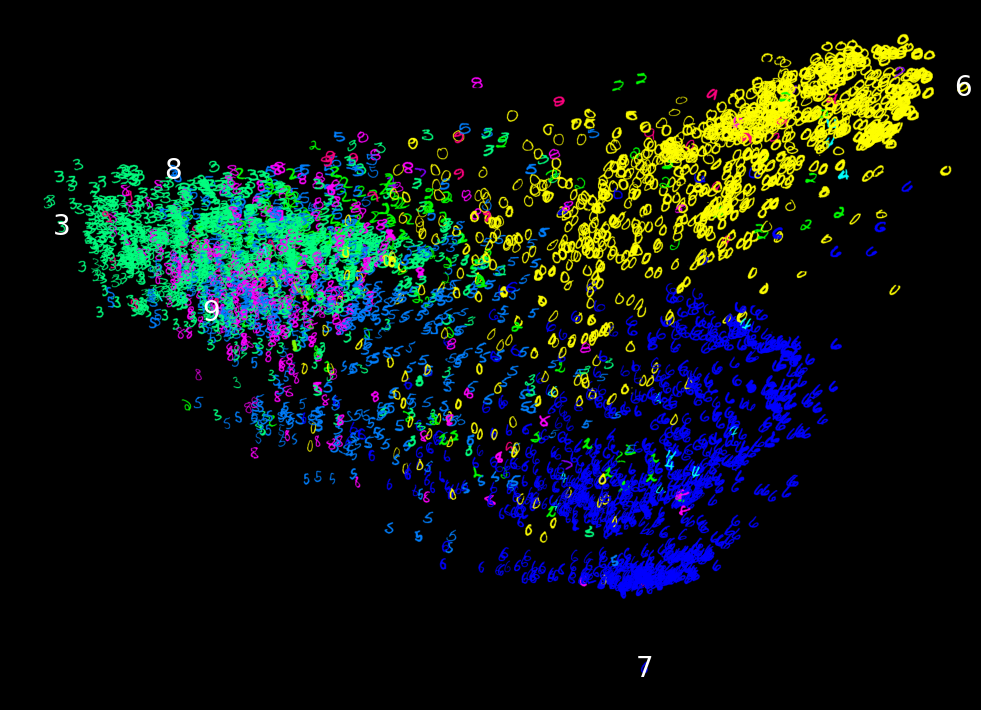

In [94]:
focus_on = np.array([3,6,7,8,9])
scatter_visualization.plot_points_from_file(config.params['file_path'], 10000, points, centroids, voltages, label_counts, 
                                            focus_on=focus_on, element='digit', size_threshold=0)

Read 10000 vectors<class 'voltagemap.VoltageMap'>
Number of landmarks: 10
Number of point_voltages with no label: 0
Plot saved to mnist_visualization.png


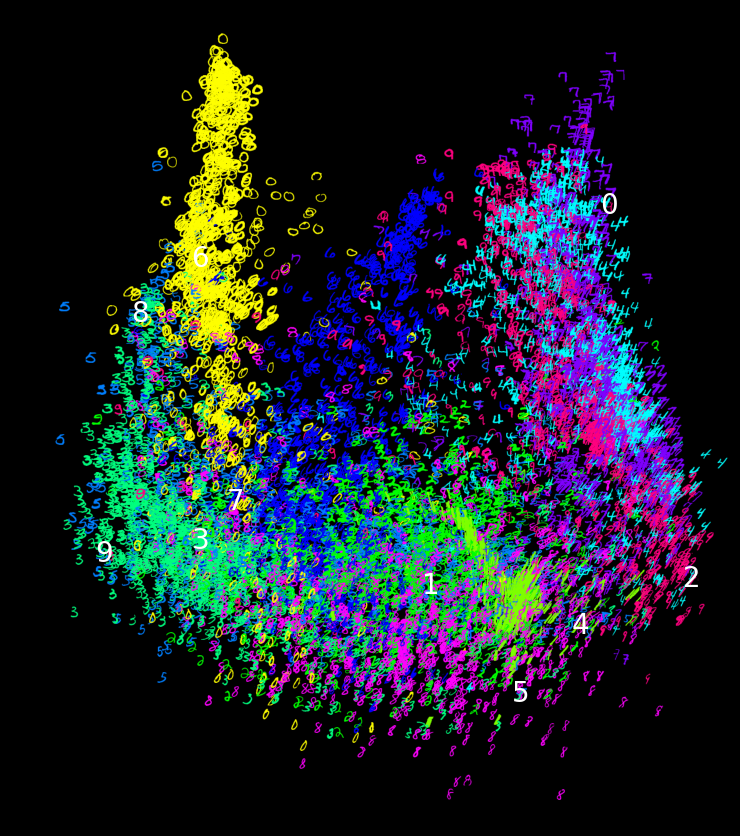

In [95]:
focus_on = np.array([0,1,2,3,4,5,6,7,8,9])
scatter_visualization.plot_points_from_file(config.params['file_path'], 10000, points, centroids, voltages, label_counts, 
                                            focus_on=focus_on, element='digit', size_threshold=0)

In [ ]:
voltage_map = voltagemap.VoltageMap()
for entry in data_to_save['voltage_map'].entries:
    voltage_map.add_solution(entry["landmark"], np.log(entry["voltages"]))

In [27]:
shuffle.tag_lines_with_random_keys(input_path='../../Voltage_Data/mnist/mnist.csv',
                                   temp_dir='../../Voltage_Data/mnist/temp',
                                   lines_per_chunk=1000)

['../../Voltage_Data/mnist/temp/tgwgb0x3.txt',
 '../../Voltage_Data/mnist/temp/76bhpf5t.txt',
 '../../Voltage_Data/mnist/temp/ysfqrg3q.txt',
 '../../Voltage_Data/mnist/temp/2dwucowj.txt',
 '../../Voltage_Data/mnist/temp/29rpy6tj.txt',
 '../../Voltage_Data/mnist/temp/z8oloodx.txt',
 '../../Voltage_Data/mnist/temp/8w7q_nov.txt',
 '../../Voltage_Data/mnist/temp/h3gccepv.txt',
 '../../Voltage_Data/mnist/temp/m1573fw9.txt',
 '../../Voltage_Data/mnist/temp/f8g9mpbt.txt',
 '../../Voltage_Data/mnist/temp/sysfu5f7.txt',
 '../../Voltage_Data/mnist/temp/_32xiw3i.txt',
 '../../Voltage_Data/mnist/temp/j2kdr6br.txt',
 '../../Voltage_Data/mnist/temp/fix0aeto.txt',
 '../../Voltage_Data/mnist/temp/neqx787l.txt',
 '../../Voltage_Data/mnist/temp/_nsn7vja.txt',
 '../../Voltage_Data/mnist/temp/xe88nzrk.txt',
 '../../Voltage_Data/mnist/temp/v83wixox.txt',
 '../../Voltage_Data/mnist/temp/1eobosdg.txt',
 '../../Voltage_Data/mnist/temp/pe5tu01n.txt',
 '../../Voltage_Data/mnist/temp/7b80zytu.txt',
 '../../Volta

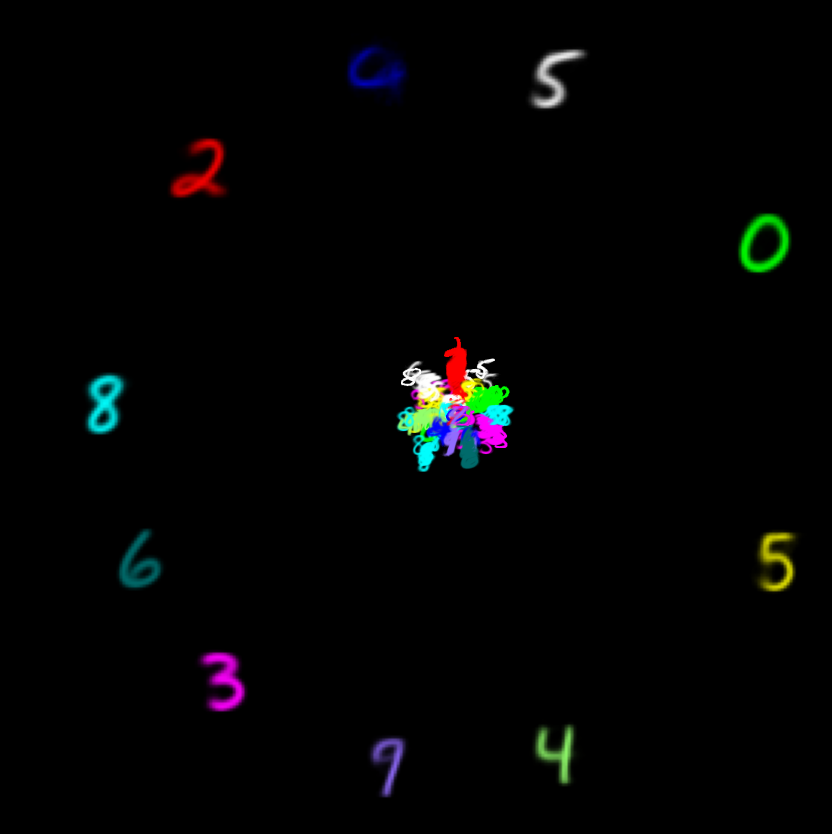

In [9]:
plot_mnist_unlabeled(data_to_save['voltage_map'], data_to_save['centroids'])

In [ ]:
def plot_mnist_digits(voltages, data, labels, transformation="mds", landmarkSize=3, alpha_actual=1, percent_size=0.02, out_file=None):
    """
    Draws the MNIST digits corresponding to each point after reducing the dimention to 2 by either PCA or MDS

    Args:
        selected_digits (List[int]): The digits to plot
        voltages (VoltageMap): The digits to plot
        data (SetOfPoints): The digits to plot
        correct (List[int]): The correct labels for each point in data
        n_outliers (Optional[int]): The number of outliers to remove
        alpha_actual (Optional[float]): The opacity of each digit, 1 is fully opaque and 0 is fully transparent
        percent_size (Optional[float]): The size of each digit, 1 is the size of the whole space and 0 is no image size
        out_file (Optional[str]): If provided, the output path to save the figure (e.g., "digits.png")
    """

    points = voltages.voltage_array()
    points=-np.log(points)

    transformed_points = visualHelpers.transform(points, transformation)
    
    fig, ax = plt.subplots(figsize=(12, 10))

    # Assign distinct colors for each digit
    colors = visualHelpers.get_distinct_colors(len(set(labels)))
    
    x_bound = (transformed_points[:, 0].min(), transformed_points[:, 0].max())
    y_bound = (transformed_points[:, 1].min(), transformed_points[:, 1].max())

    image_size = (x_bound[1] + y_bound[1] - x_bound[0] - y_bound[0]) * percent_size / 2
    
    for i in range(transformed_points.shape[0]):
        alpha_mask = np.clip(data[i].reshape(28, 28), 0, 255) / 255

        point_voltages = points[i]

        label = labels[i]

        if (label != None):
            color = np.array(colors[int(label)])
            
            size = 1
            if (np.max(point_voltages) == 1):
                size = landmarkSize
    
            # Create RGBA image
            rgb_image = np.zeros((28, 28, 4))
    
            for c in range(3):
                rgb_image[..., c] = color[c]
            rgb_image[..., 3] = alpha_mask * alpha_actual  # Alpha from pixel intensity
    
            x, y = transformed_points[i]
            ax.imshow(rgb_image, extent=(x - image_size * size, x + image_size * size, y - image_size * size, y + image_size * size), origin='upper')
    
    ax.set_xlim(x_bound[0] - image_size * landmarkSize, x_bound[1] + image_size * landmarkSize)
    ax.set_ylim(y_bound[0] - image_size * landmarkSize, y_bound[1] + image_size * landmarkSize)
    ax.set_facecolor('black')
    fig.patch.set_facecolor('black')
    plt.title("Visualization of Digits")

    visualHelpers.standard_save_display(out_file)

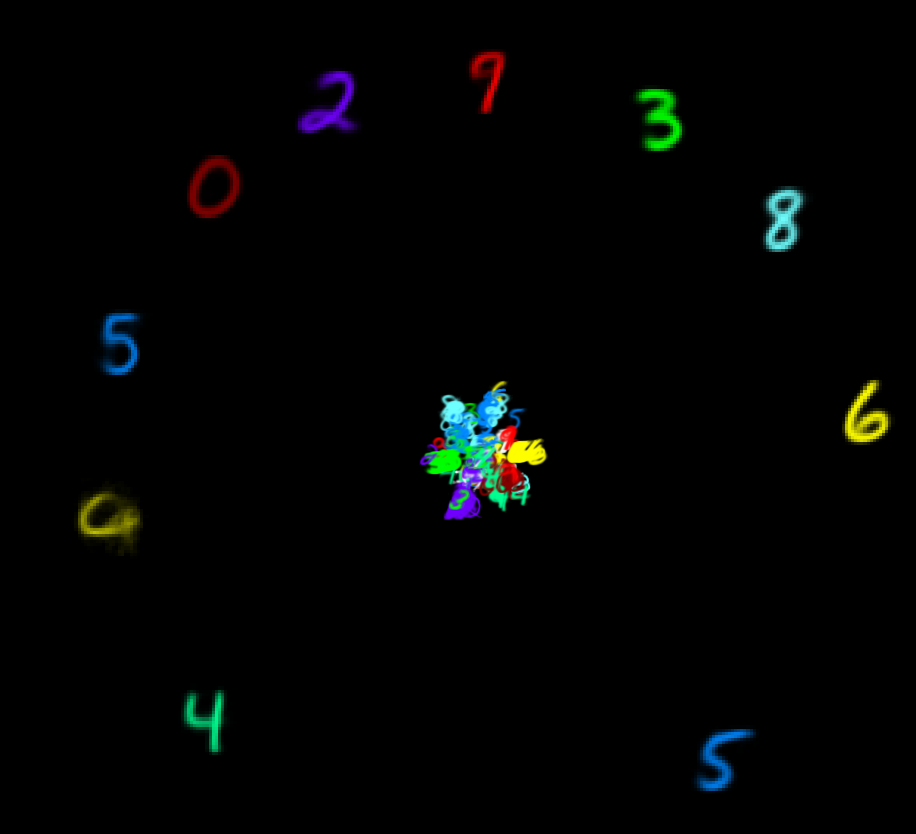

In [ ]:
scatter_visualization.plot_mnist_digits(voltage_map, data_to_save['centroids'], data_to_save['majority_labels'])

In [10]:
def plot_with_landmarks_colored(data_to_save):
    va = data_to_save['voltage_map'].voltage_array()
    centroids = visualHelpers.transform(va, 'mds')
    all_voltages = data_to_save['all_voltages'].entries
    
    # Collect all landmark indices
    landmark_indices = {entry['landmark'].index for entry in all_voltages}

    plt.figure(figsize=(8, 6))
    for i, point in enumerate(centroids):
        if np.max(va[i]) == 1:
            plt.scatter(point[0], point[1], color='yellow', label='Landmark' if i == list(landmark_indices)[0] else "")
        else:
            plt.scatter(point[0], point[1], color='blue', s=10)

    plt.title("Centroid Points with Landmarks Highlighted")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.grid(True)
    plt.show()

/tmp/ipykernel_33882/3270587395.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


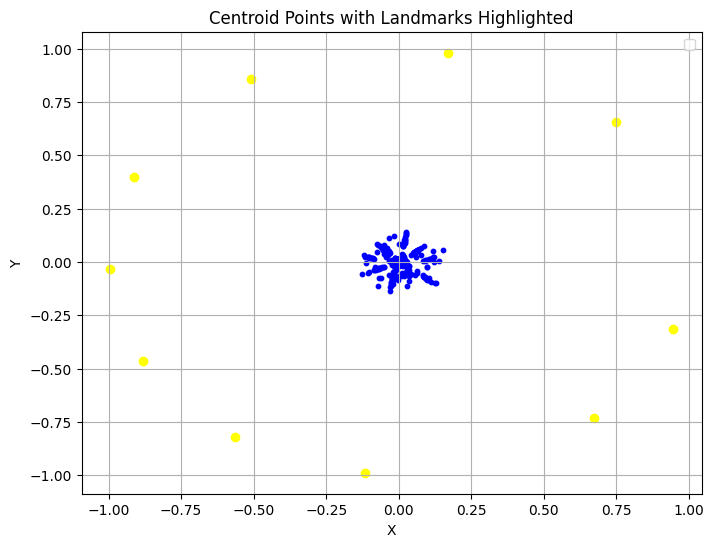

In [11]:
plot_with_landmarks_colored(data_to_save)

In [56]:
temp_points, temp_counters, temp_majority_labels, temp_label_counts, rms=kmeans.Streaming_Kmeans(config.params['file_path'])

Read 10000 vectors
Estimated max pairwise distance squared, FAISS) = 16654926.0000
 Estimated minimum distance squared = 71864.0000
10 vectors in index after adding initial centroid
Read 20000 vectors
number of centroids: 1000, max_centroids: 1000
Reached maximum number of centroids: 1000
Read 30000 vectors
refining vectors
sorted_sizes=[105  84  77  74  63]
too_small=43, rms=55.42711244679316, finished=False

refining vectors
sorted_sizes=[102  81  75  71  61]
too_small=43, rms=52.808899431164626, finished=False

refining vectors
sorted_sizes=[99 78 76 70 60]
too_small=43, rms=50.60987689395412, finished=False

refining vectors
sorted_sizes=[92 77 77 72 57]
too_small=42, rms=48.81417300545053, finished=False

refining vectors
sorted_sizes=[86 78 78 70 54]
too_small=42, rms=47.25536914010024, finished=False

refining vectors
sorted_sizes=[85 77 77 65 56]
too_small=42, rms=45.96289959909932, finished=False

refining vectors
sorted_sizes=[81 77 77 65 55]
too_small=42, rms=44.875989205426

In [57]:
temp_counters

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,